In [1]:
import os
import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt
import dask.dataframe as dd


df = dd.read_parquet("s3://shboost2024/shboost_08july2024_pub.parq/*.parquet",
                     storage_options={ 'use_ssl': True,
                                      "anon":"True",
                                      "client_kwargs":dict(endpoint_url='https://s3.data.aip.de:9000')})

In [2]:
print(len(df))

217974770


In [3]:
df.head()

,xgb_av,xgbdist_av_mean,xgbdist_av_std,xgb_logteff,xgbdist_logteff_mean,xgbdist_logteff_std,xgb_logg,xgbdist_logg_mean,xgbdist_logg_std,xgb_met,...,vyg,vzg,vrg,vphig,xgb_inputflag,xgb_av_outputflag,xgb_logteff_outputflag,xgb_logg_outputflag,xgb_met_outputflag,xgb_mass_outputflag
source_id,,,,,,,,,,,,,,,,,,,,,
13469017618176,0.123056,0.123875,0.072523,3.715749,3.714313,0.012467,4.581601,4.583405,0.129925,-0.449698,...,NaN,NaN,NaN,NaN,XP5pGBPRPJHKsW1W2W3W4,0,0,0,0,0
376101696361472,0.172166,0.160751,0.072109,3.740226,3.740698,0.009750,4.483738,4.476311,0.141070,-0.283471,...,NaN,NaN,NaN,NaN,XP5pGBPRPJHKsW1W2W3W4,0,0,0,0,0
743652113204224,0.152945,0.155526,0.061350,3.727308,3.728032,0.007208,4.474120,4.462936,0.067824,-0.028203,...,NaN,NaN,NaN,NaN,XP5pGBPRPJHKsW1W2W3W4,0,0,0,0,0
1643808538917376,0.127599,0.135679,0.050845,3.683411,3.683947,0.007085,4.606787,4.606959,0.029999,-0.210136,...,NaN,NaN,NaN,NaN,XP5pGBPRPJHKsW1W2W3W4,0,0,0,0,0
2002558567225728,0.209449,0.210985,0.063578,3.782185,3.782310,0.007625,4.160272,4.148098,0.094334,-0.306414,...,223.320358,15.275782,18.767399,-223.093491,XP5pGBPRPJHKsW1W2W3W4,0,0,0,0,0


In [4]:
dfplot=df.sample(frac=0.01).persist()

In [5]:
dfplot=dfplot.compute()

In [6]:
# plotting xg, yg, bprp0, mg0 maps

<AxesSubplot:xlabel='bprp0', ylabel='mg0'>

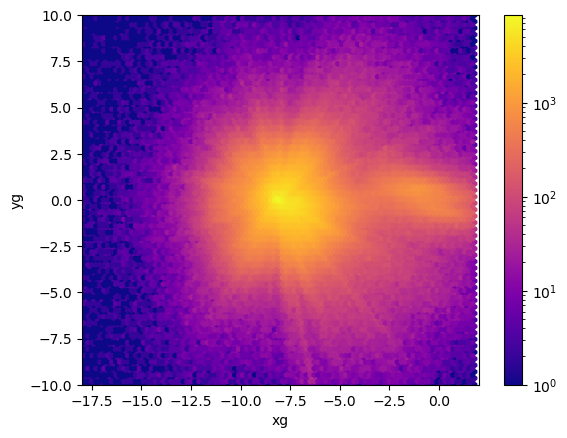

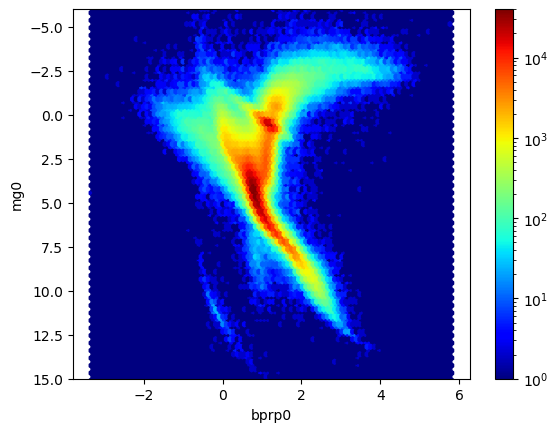

In [9]:
fig, ax = plt.subplots()
sel=(np.abs(dfplot.xg+8.2)<10)&(np.abs(dfplot.yg)<10)
dfplot[sel].plot(x='xg',y='yg',kind='hexbin', xlim=(-18,2),ylim=(-10,10), norm=mpl.colors.LogNorm(),cmap="plasma",ax=ax)
fig, ax = plt.subplots()
dfplot[sel].plot(x='bprp0',y='mg0',kind='hexbin', ylim=(15,-6), norm=mpl.colors.LogNorm(),cmap="jet", ax=ax)